In [801]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [802]:
df=pd.read_csv('/content/census-income .csv')
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [803]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  annual_income   32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [804]:
#Eda
df.isnull().sum().sum()

np.int64(0)

In [805]:
df.duplicated().sum()

np.int64(24)

In [806]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

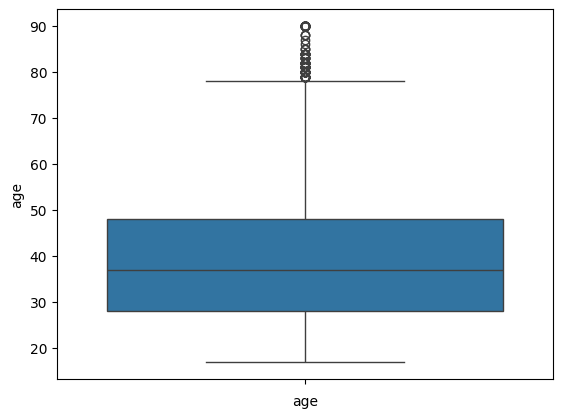

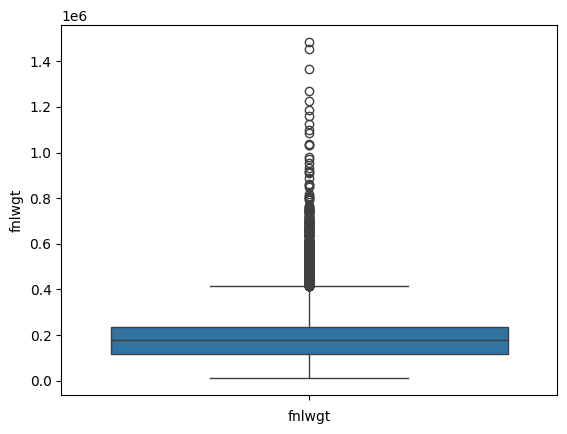

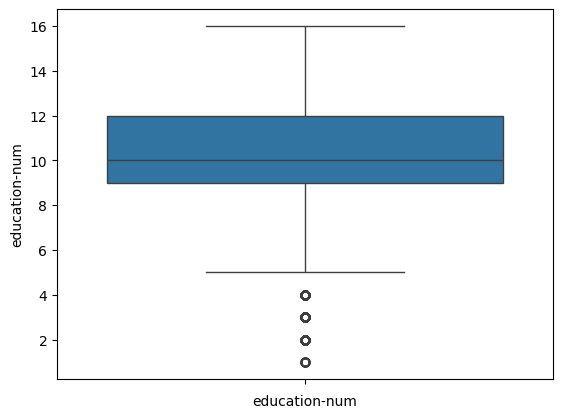

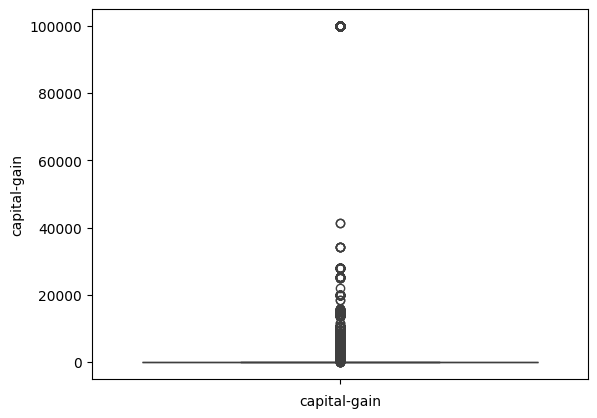

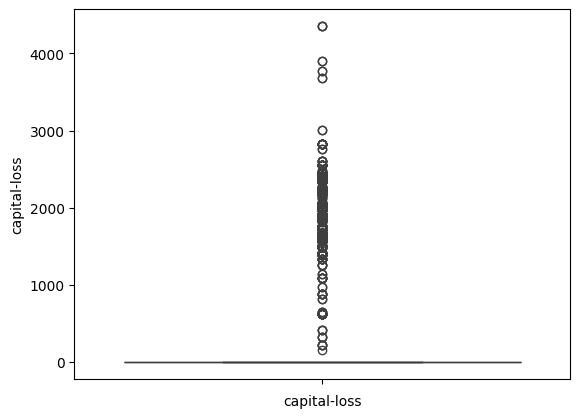

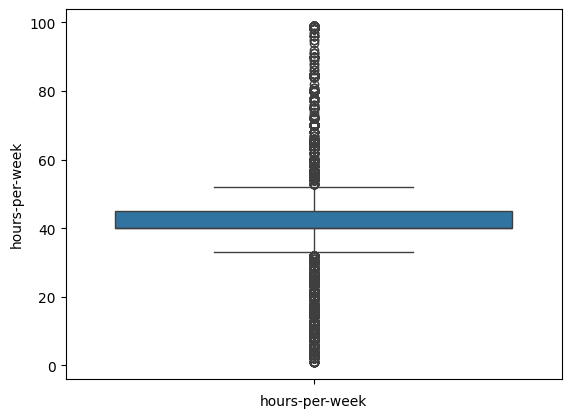

In [807]:
for col in df.columns:
  if (df[col].dtype !='object'):
    sns.boxplot(df[col])
    plt.xlabel(col)
    plt.show()

In [808]:
df.shape

(32537, 15)

In [809]:
out_list=['age', 'fnlwgt', 'hours-per-week']
for col in out_list:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)

  IQR= Q3-Q1

  LB=Q1-1.5*(IQR)
  UB=Q3+1.5*(IQR)

  df=df[(df[col]>=LB) & (df[col]<=UB)]
df.shape

(22740, 15)

In [810]:
32537-30303

2234

In [811]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

for col in df.columns:
  if(df[col].dtype=='object'):
    df[col]=le.fit_transform(df[col])

In [812]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22740 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             22740 non-null  int64
 1   workclass       22740 non-null  int64
 2   fnlwgt          22740 non-null  int64
 3   education       22740 non-null  int64
 4   education-num   22740 non-null  int64
 5   marital-status  22740 non-null  int64
 6   occupation      22740 non-null  int64
 7   relationship    22740 non-null  int64
 8   race            22740 non-null  int64
 9   sex             22740 non-null  int64
 10  capital-gain    22740 non-null  int64
 11  capital-loss    22740 non-null  int64
 12  hours-per-week  22740 non-null  int64
 13  native-country  22740 non-null  int64
 14  annual_income   22740 non-null  int64
dtypes: int64(15)
memory usage: 2.8 MB


# Linear

In [813]:
x=df.drop('hours-per-week',axis=1)
y=df['hours-per-week']

In [814]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.80)

from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [815]:
model_answers=model.predict(x_test)
model_answers

array([39.45541951, 41.1704676 , 39.85127556, ..., 41.19879071,
       41.54650776, 44.18372539])

In [816]:
from sklearn.metrics import r2_score
r2_score(model_answers,y_test)*100

-1055.098704616527

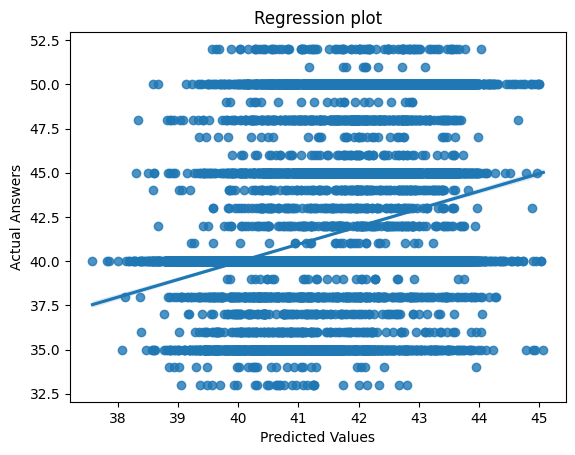

In [817]:
sns.regplot(x=model_answers,y=y_test)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Answers')
plt.title("Regression plot")
plt.show()

In [818]:
#mess but i dont know how to fix it but i am trying
# mostly menaing linear reg is not a good fit by the looks of it.

# Logistic

In [819]:
x=df.drop('annual_income',axis=1)
y=df['annual_income']

In [820]:
vif_data=pd.DataFrame()
vif_data

""


In [821]:
vif_data['Features']=x.columns
vif_data

,Features
0,age
1,workclass
2,fnlwgt
3,education
4,education-num
5,marital-status
6,occupation
7,relationship
8,race
9,sex


In [822]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_values=[]
for i in range(len(x.columns)):
  vif=variance_inflation_factor(x.values,i)
  vif_values.append(vif)

vif_data['VIF_Values']=vif_values

vif_data

,Features,VIF_Values
0,age,11.341219
1,workclass,9.281330
2,fnlwgt,5.176729
3,education,10.001920
4,education-num,19.912635
5,marital-status,3.935989
6,occupation,3.625878
7,relationship,2.617227
8,race,19.012513
9,sex,4.939594


In [823]:
x.drop('hours-per-week',axis=1,inplace=True)

vif_data=pd.DataFrame()
vif_data['Features']=x.columns

vif_values=[]
for i in range(len(x.columns)):
  vif=variance_inflation_factor(x.values,i)
  vif_values.append(vif)

vif_data['VIF_Values']=vif_values

vif_data

,Features,VIF_Values
0,age,9.987991
1,workclass,8.859586
2,fnlwgt,4.995898
3,education,9.880343
4,education-num,17.956011
5,marital-status,3.797497
6,occupation,3.604035
7,relationship,2.503786
8,race,17.228407
9,sex,4.587168


In [824]:
x.drop('native-country',axis=1,inplace=True)

vif_data=pd.DataFrame()
vif_data['Features']=x.columns

vif_values=[]
for i in range(len(x.columns)):
  vif=variance_inflation_factor(x.values,i)
  vif_values.append(vif)

vif_data['VIF_Values']=vif_values

vif_data

,Features,VIF_Values
0,age,9.481569
1,workclass,8.765706
2,fnlwgt,4.973591
3,education,9.699792
4,education-num,17.322667
5,marital-status,3.740844
6,occupation,3.602604
7,relationship,2.430813
8,race,15.132041
9,sex,4.521699


In [825]:
x.drop('education-num',axis=1,inplace=True)

vif_data=pd.DataFrame()
vif_data['Features']=x.columns

vif_values=[]
for i in range(len(x.columns)):
  vif=variance_inflation_factor(x.values,i)
  vif_values.append(vif)

vif_data['VIF_Values']=vif_values

vif_data

,Features,VIF_Values
0,age,9.012198
1,workclass,8.643655
2,fnlwgt,4.945665
3,education,7.798417
4,marital-status,3.679561
5,occupation,3.492599
6,relationship,2.418061
7,race,14.317437
8,sex,4.509498
9,capital-gain,1.032340


In [826]:
x.drop('race',axis=1,inplace=True)

vif_data=pd.DataFrame()
vif_data['Features']=x.columns

vif_values=[]
for i in range(len(x.columns)):
  vif=variance_inflation_factor(x.values,i)
  vif_values.append(vif)

vif_data['VIF_Values']=vif_values

vif_data

,Features,VIF_Values
0,age,7.863733
1,workclass,8.162448
2,fnlwgt,4.798608
3,education,7.283801
4,marital-status,3.594180
5,occupation,3.475909
6,relationship,2.362124
7,sex,4.275422
8,capital-gain,1.032021
9,capital-loss,1.057257


In [827]:
x.drop('workclass',axis=1,inplace=True)

vif_data=pd.DataFrame()
vif_data['Features']=x.columns

vif_values=[]
for i in range(len(x.columns)):
  vif=variance_inflation_factor(x.values,i)
  vif_values.append(vif)

vif_data['VIF_Values']=vif_values

vif_data

,Features,VIF_Values
0,age,7.153896
1,fnlwgt,4.736410
2,education,6.957666
3,marital-status,3.543927
4,occupation,3.239864
5,relationship,2.316178
6,sex,4.114248
7,capital-gain,1.031941
8,capital-loss,1.057235


In [828]:
x.drop('age',axis=1,inplace=True)

vif_data=pd.DataFrame()
vif_data['Features']=x.columns

vif_values=[]
for i in range(len(x.columns)):
  vif=variance_inflation_factor(x.values,i)
  vif_values.append(vif)

vif_data['VIF_Values']=vif_values

vif_data

,Features,VIF_Values
0,fnlwgt,4.478637
1,education,5.788414
2,marital-status,3.543391
3,occupation,3.113444
4,relationship,2.279423
5,sex,3.782813
6,capital-gain,1.026835
7,capital-loss,1.053161


In [829]:
x.drop('education',axis=1,inplace=True)

vif_data=pd.DataFrame()
vif_data['Features']=x.columns

vif_values=[]
for i in range(len(x.columns)):
  vif=variance_inflation_factor(x.values,i)
  vif_values.append(vif)

vif_data['VIF_Values']=vif_values

vif_data

,Features,VIF_Values
0,fnlwgt,4.083235
1,marital-status,3.383098
2,occupation,2.974665
3,relationship,2.059623
4,sex,3.303149
5,capital-gain,1.024353
6,capital-loss,1.050326


In [861]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.80,random_state=42)

In [862]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

In [863]:
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [864]:
y_pred=model.predict(x_test)

In [865]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred,y_test)*100

78.32014072119613